# Random Forest - Nada

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import plot_tree
!pip install eli5 lime shap
import eli5
from eli5.sklearn import PermutationImportance
from sklearn.inspection import PartialDependenceDisplay
from lime import lime_tabular
import shap

In [ ]:
x = data.drop(columns=["stroke_risk_percentage"])
y = data["stroke_risk_percentage"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [ ]:
rf = RandomForestRegressor(n_estimators = 400, max_depth = None, min_samples_split = 2, min_samples_leaf = 1, bootstrap = True, oob_score = False, random_state=0)

history = rf.fit(x_train, y_train)

In [ ]:
predictions = rf.predict(x_test)

In [ ]:
MSE = mean_squared_error(y_test, predictions)

MAE = mean_absolute_error(y_test, predictions)

R2 = r2_score(y_test, predictions)

print(f"Mean Squared Error: {MSE}")
print(f'Mean Absolute Error (MAE): {MAE}')
print(f'R-squared (R2): {R2}')

Mean Squared Error: 48.1759621842011
Mean Absolute Error (MAE): 5.024658517435232
R-squared (R2): 0.9497152032369891


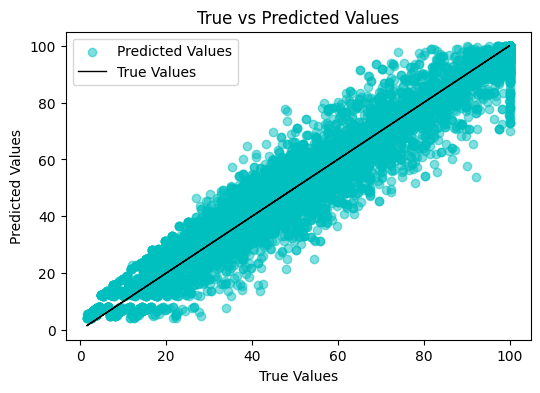

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(y_test, predictions, c="c", alpha=0.5, label="Predicted Values")

ax.plot(y_test, y_test, c="k", lw=1, label="True Values")

ax.set_xlabel('True Values')
ax.set_ylabel('Predicted Values')
ax.set_title('True vs Predicted Values')
ax.legend()

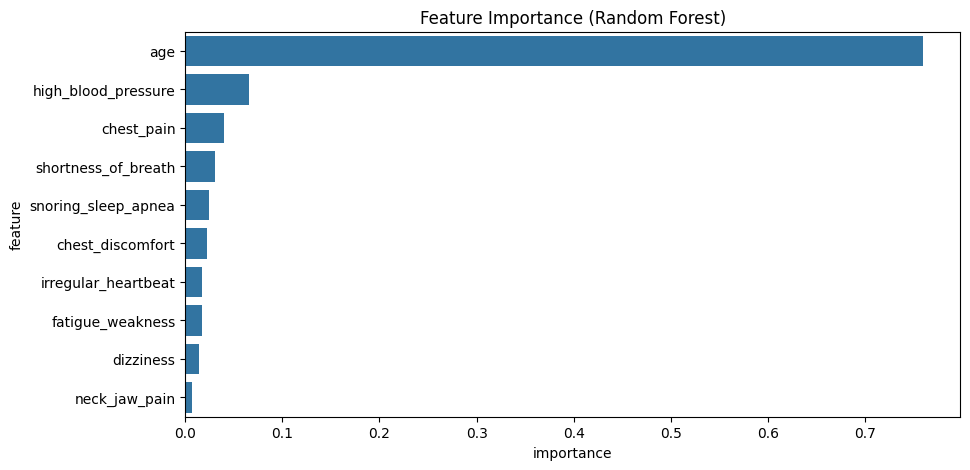

In [ ]:
features_importance = pd.DataFrame({'feature': x.columns, 'importance': rf.feature_importances_})
features_importance = features_importance.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='importance', y='feature', data=features_importance)
plt.title('Feature Importance (Random Forest)')
plt.show()

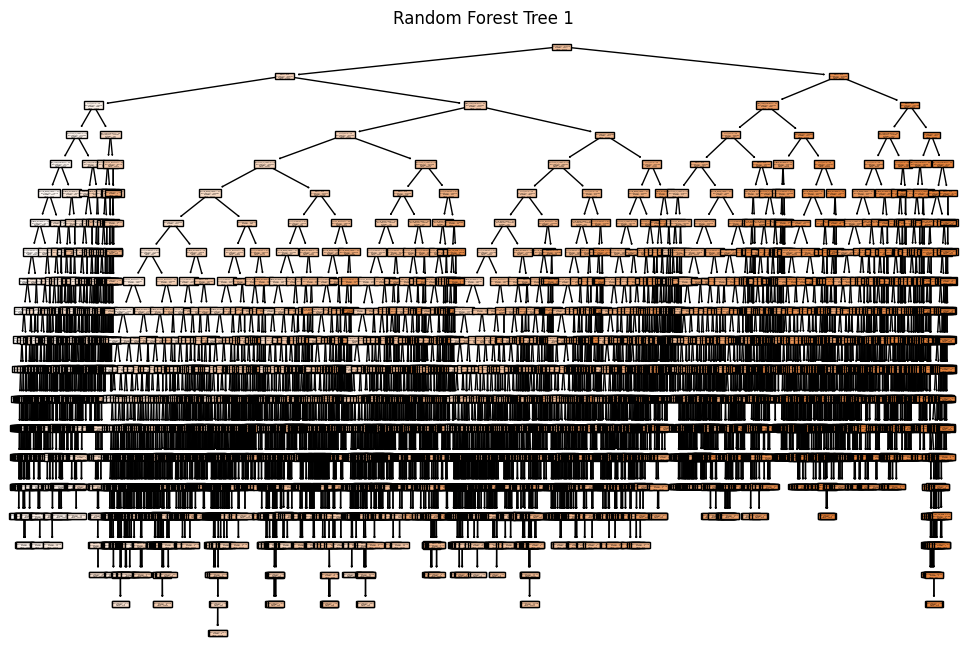

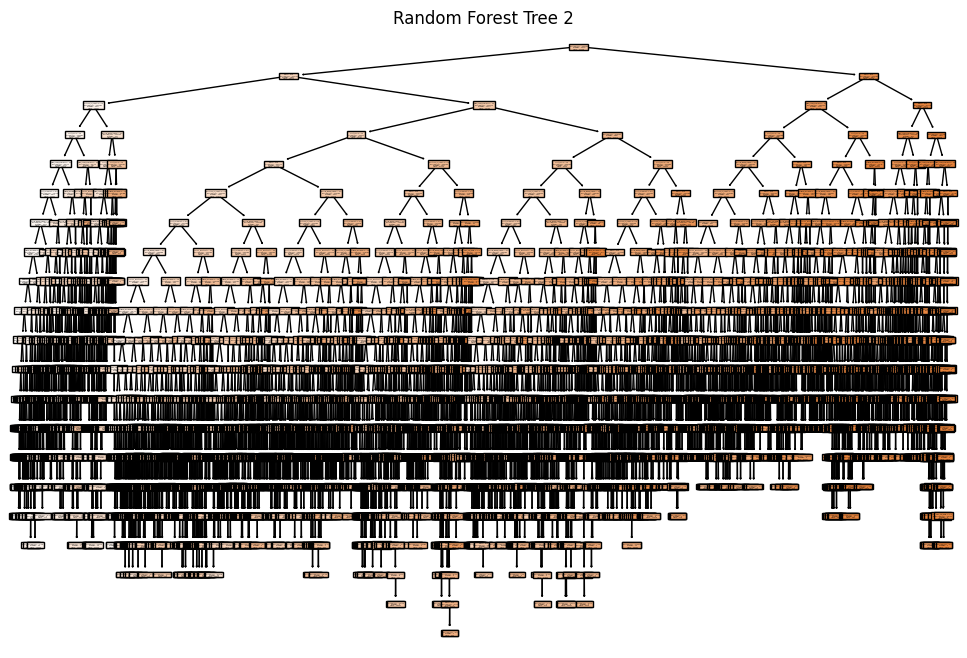

In [ ]:
# The trees in the random forest are too complex/big to be able to use them for interpretability
for i in range(2):
    plt.figure(figsize=(12, 8))
    plot_tree(rf.estimators_[i], feature_names=x.columns, filled=True)
    plt.title(f'Random Forest Tree {i+1}')
    plt.show()

In [ ]:
eli5.show_weights(rf, feature_names=x.columns.tolist())

Weight,Feature
0.7599 ± 0.0060,age
0.0660 ± 0.0040,high_blood_pressure
0.0401 ± 0.0023,chest_pain
0.0306 ± 0.0018,shortness_of_breath
0.0249 ± 0.0020,snoring_sleep_apnea
0.0229 ± 0.0014,chest_discomfort
0.0173 ± 0.0014,irregular_heartbeat
0.0172 ± 0.0010,fatigue_weakness
0.0138 ± 0.0008,dizziness
0.0075 ± 0.0006,neck_jaw_pain


In [ ]:
perm = PermutationImportance(rf, random_state=0).fit(x_test, y_test)
display(eli5.show_weights(perm, feature_names=x.columns.tolist()))

Weight,Feature
0.9136 ± 0.0048,age
0.1369 ± 0.0021,high_blood_pressure
0.0900 ± 0.0034,chest_pain
0.0668 ± 0.0020,shortness_of_breath
0.0560 ± 0.0006,snoring_sleep_apnea
0.0544 ± 0.0029,chest_discomfort
0.0392 ± 0.0022,irregular_heartbeat
0.0390 ± 0.0010,fatigue_weakness
0.0320 ± 0.0013,dizziness
0.0171 ± 0.0012,neck_jaw_pain


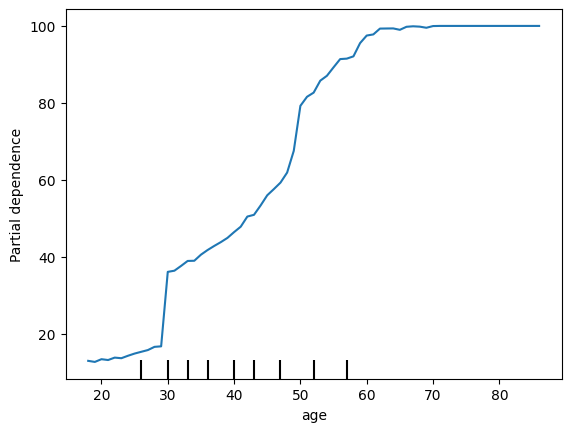

In [ ]:
PartialDependenceDisplay.from_estimator(rf, x, features=[0])

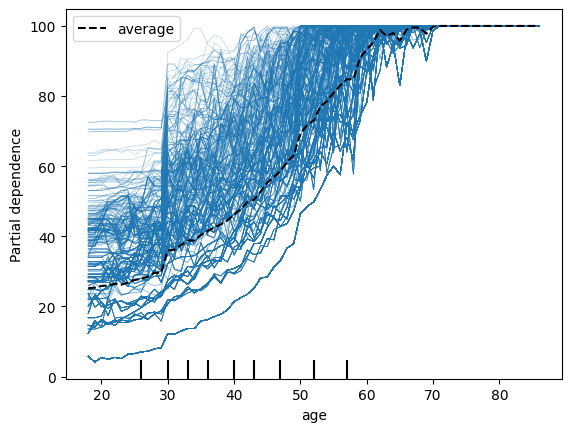

In [ ]:
PartialDependenceDisplay.from_estimator(rf, x, features=[0], kind="both", pd_line_kw={'color': 'black'})

<Axes: xlabel='importance', ylabel='feature'>

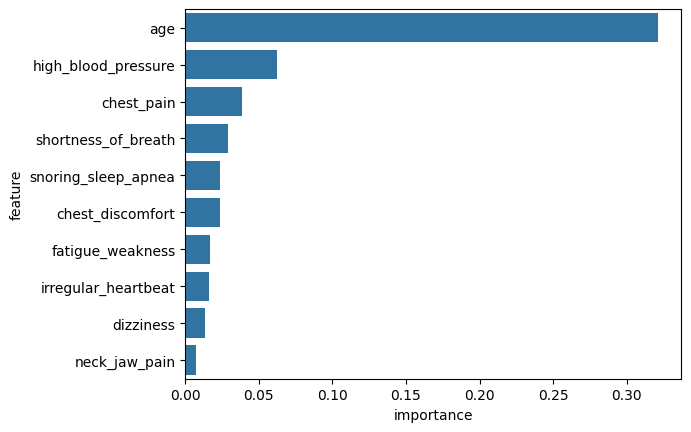

In [ ]:
importance = []

rf2 = RandomForestRegressor(n_estimators = 400, max_depth = None, min_samples_split = 2, min_samples_leaf = 1, bootstrap = True, oob_score = False, random_state=0)

for col in x.columns:
  x_col_removed = x.drop(columns=[col])
  x_train2, x_test2, y_train2, y_test2 = train_test_split(x_col_removed, y, test_size=0.2, random_state=0)

  history2 = rf2.fit(x_train2, y_train2)

  predictions2 = rf2.predict(x_test2)
  R2_cols_rem = r2_score(y_test2, predictions2)

  difference = R2 - R2_cols_rem
  importance.append({"feature": col, "importance": difference})

res_df = pd.DataFrame(importance)
res_df = res_df.sort_values(by="importance", ascending=False)

sns.barplot(data=res_df, x="importance", y="feature")

/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

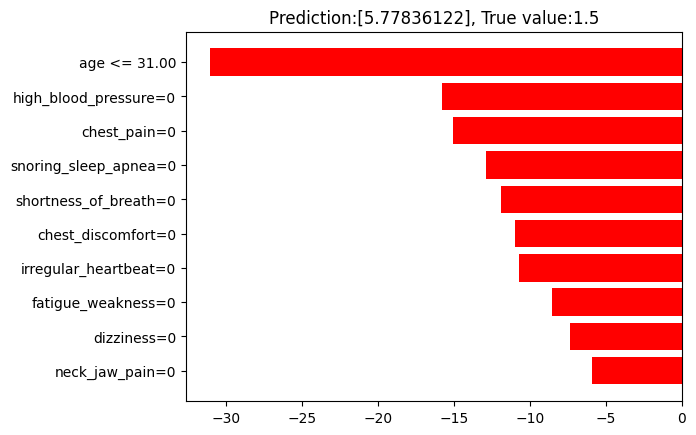

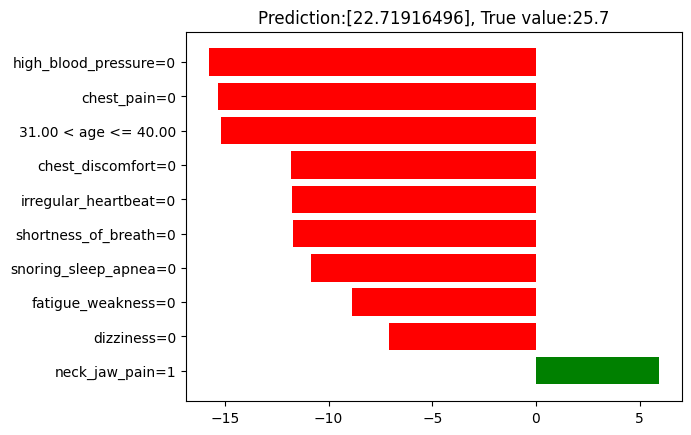

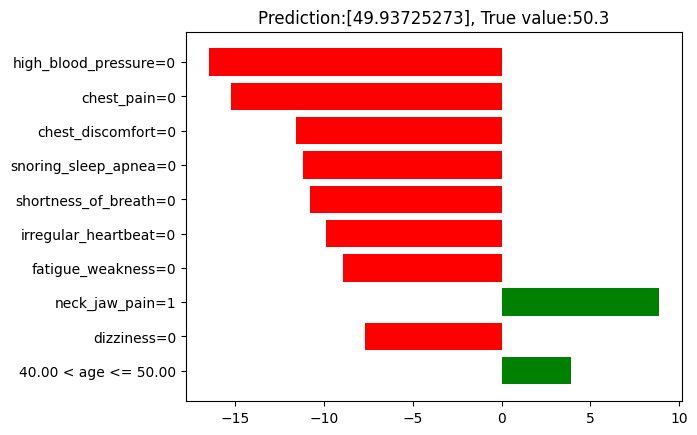

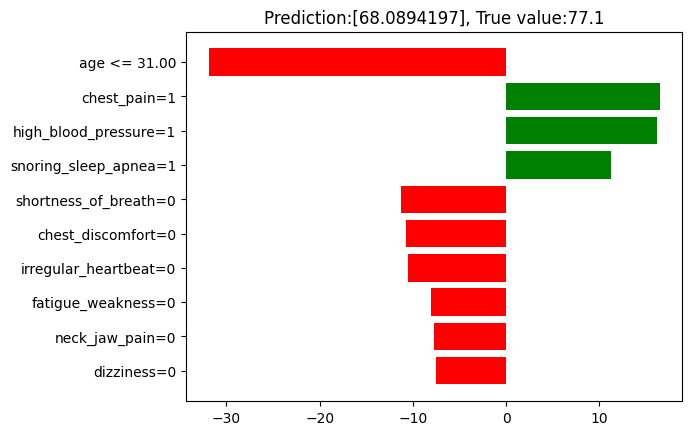

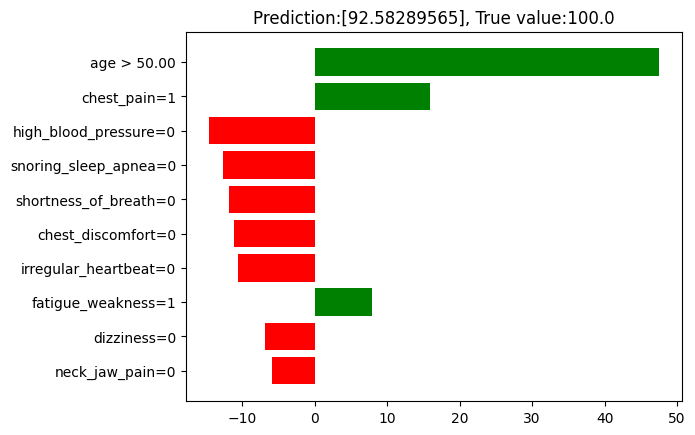

In [ ]:
explainer = lime_tabular.LimeTabularExplainer(training_data=x_train.to_numpy(), feature_names=x.columns, categorical_features=[1,2,3,4,5,6,7,8,9], mode="regression")

def model_predict(data):
  return rf.predict(data)

def get_examples(x_test, y_test):
  examples = {}
  ranges = [0,25,50,75,100]
  percentiles = np.percentile(y_test,ranges)
  for p in percentiles:
    index = np.argmin(np.abs(y_test - p))
    examples[index] = x_test.iloc[index]

  return examples

examples = get_examples(x_test, y_test)

for i, item in examples.items():
    explanation = explainer.explain_instance(
        data_row=item,
        predict_fn=model_predict,
        num_features=10
    )

    explanation.as_pyplot_figure()
    plt.title("Prediction:" + str(rf.predict(x_test.iloc[[i]])) + ", True value:" + str(y_test.iloc[i]))

In [ ]:
def get_examples_shap(x_test, y_test):
  examples = []
  ranges = [0,25,50,75,100]
  percentiles = np.percentile(y_test,ranges)
  for p in percentiles:
    index = np.argmin(np.abs(y_test - p))
    examples.append(x_test.iloc[index])

  return examples

examples2 = get_examples_shap(x_test, y_test)

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(pd.DataFrame(examples2))

In [ ]:
shap.initjs()
for i in range(5):
  display(shap.force_plot(
      explainer.expected_value,
      shap_values[i],
      examples2[i]
  ))

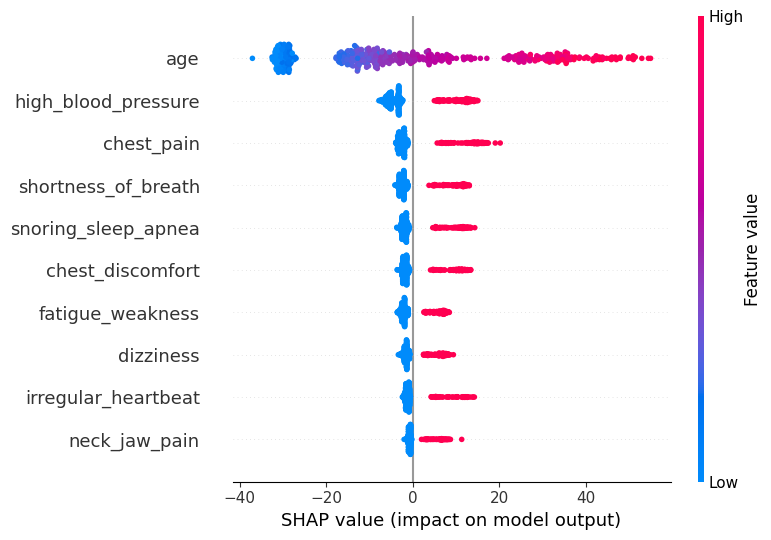

In [ ]:
x_test_sample = x_test.sample(500, random_state=0)
shap_values2 = explainer.shap_values(x_test_sample)
shap.summary_plot(shap_values2, x_test_sample)